In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [186]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [187]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [188]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_1.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657402,0.631595
1,3.900000e-09,0.715501,0.690976
2,5.900000e-09,0.768871,0.746646
3,7.900000e-09,0.815328,0.796316
4,9.900000e-09,0.852969,0.837955
...,...,...,...
535,6.390000e-08,0.675286,0.899248
536,6.590000e-08,0.495719,0.301764
537,6.790000e-08,0.732198,0.893686
538,6.990000e-08,0.441232,0.313137


In [189]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [190]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

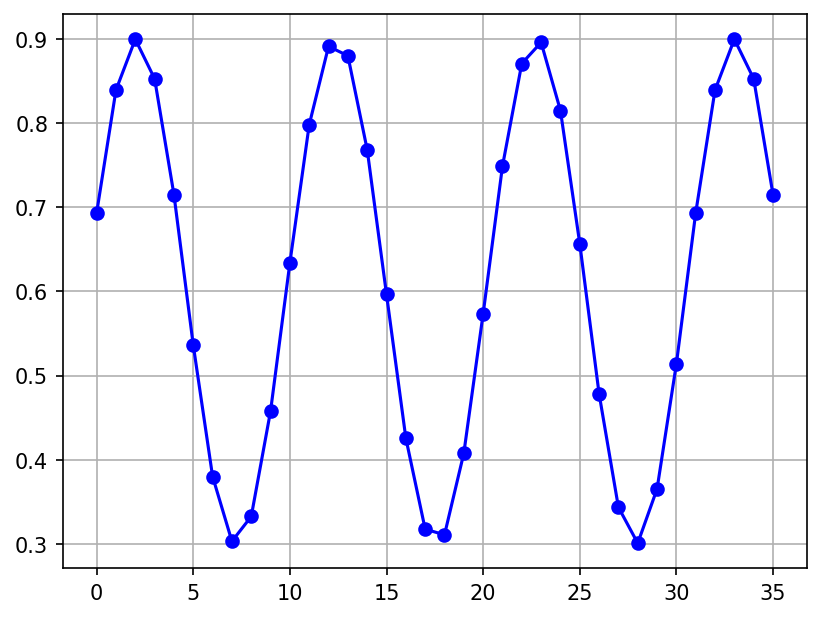

In [191]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [192]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-3.0662514173342796e-08
-9.234753656064262e-08
2.0330212434685782e-07
-4.297044525460209e-09
6.6595971063861e-08
-1.7925664283642807e-06
-1.033378461297323e-06
3.6458323354290775e-08
9.379697899623264e-08
8.60187771016002e-07
-3.3228269118826135e-06
-6.395979922801135e-08
-2.930650225023582e-06
1.1735986806588762e-08
5.8014891433212825e-06
-9.35684211218185e-07
-2.245250431869055e-06
7.693363054642576e-08
1.4265448267401882e-06
-6.3032015137721775e-09
-3.072660122967035e-07
3.232786009349374e-06
-6.331813276971889e-07
2.1426658698875046e-06
1.5182060851057183e-06
2.445558730282842e-08
-3.4570040412712277e-07
1.920768508716202e-05
-1.48102833690184e-07
2.345939834158711e-06


In [193]:
# Analysis
vdd = 1.2
vt = 0.47
cpss = 0
cpls = 55e-15
cb = 830e-15
cpss = cb/10
vgs = vdd*cb/(cb+cpls)
vov = vgs - vt
print(vov)
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
fbw= 6.6e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cpss/cb+0.11)**2)
print(fbw/1e6)

0.6554237288135594
6600.0


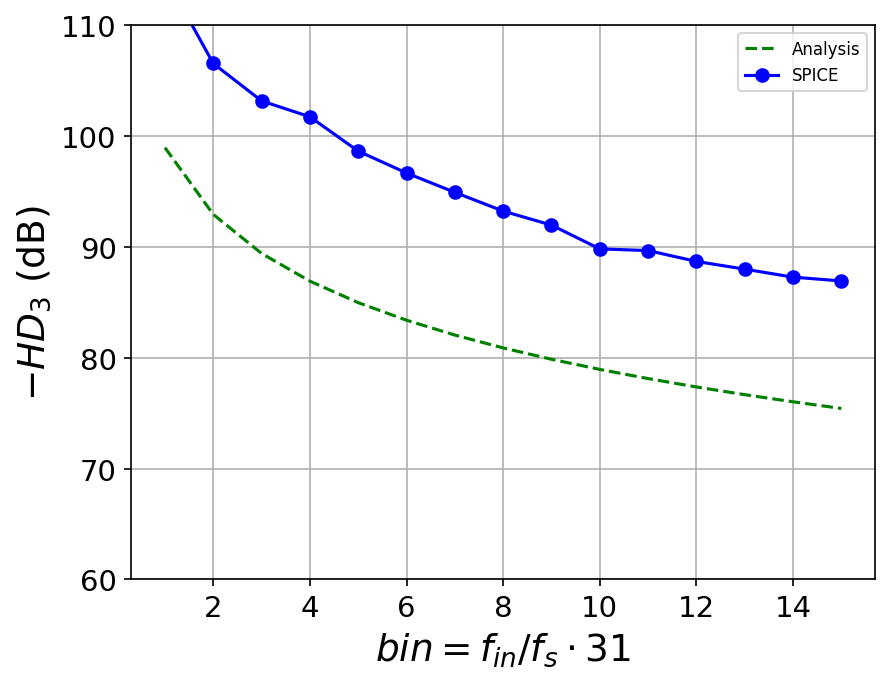

In [194]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='SPICE')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

-3.0662514173342796e-08
-9.234753656064262e-08
2.0330212434685782e-07
-4.297044525460209e-09
6.6595971063861e-08
-1.7925664283642807e-06
-1.033378461297323e-06
3.6458323354290775e-08
9.379697899623264e-08
8.60187771016002e-07
-3.3228269118826135e-06
-6.395979922801135e-08
-2.930650225023582e-06
1.1735986806588762e-08
5.8014891433212825e-06


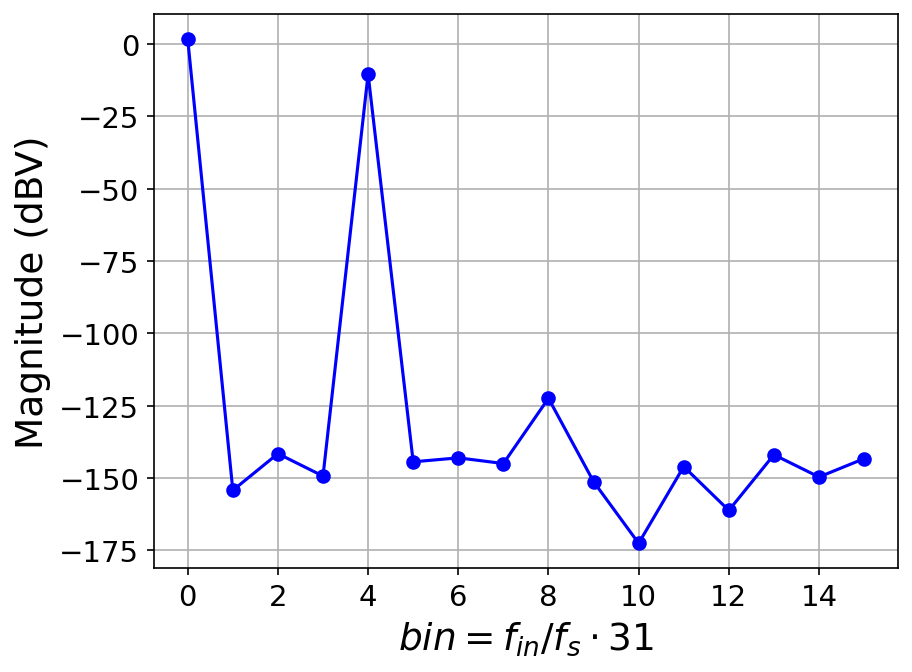

In [196]:
spec_dbv_out = compute_spectra(bins, vi, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
